# GRU Baseline vs Embed-RUL — Train on FD001, Test on All Four

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'GPUs available: {torch.cuda.device_count()}')

Device: cuda
GPUs available: 2


## Parameters

In [15]:
# GRU
GRU_SEQ_LEN = 25
GRU_HIDDEN  = 64
GRU_LAYERS  = 2
GRU_EPOCHS  = 100
GRU_LR    = 5e-4
GRU_BATCH = 32
RUL_CLIP    = 125

# Embed-RUL — paper parameters
W           = 30
N_PCA       = 15     # paper used p=2
C_L         = 55
DROPOUT     = 0.2
ED_EPOCHS   = 100
ED_LR       = 0.001
ED_BATCH    = 32

# RUL estimation — paper parameters
TAU         = 200
LAMBDA      = 0.005
ALPHA       = 0.95
R_MAX       = 120    # paper hyperparameter

## Dataset Paths

In [3]:
PATHS = {
    'FD001': {
        'train': '/kaggle/input/datasets/fawazmallick01/c-mapss/train_FD001.txt',
        'test':  '/kaggle/input/datasets/fawazmallick01/c-mapss/test_FD001.txt',
        'rul':   '/kaggle/input/datasets/fawazmallick01/c-mapss/RUL_FD001.txt',
    },
    'FD002': {
        'test': '/kaggle/input/datasets/fawazmallick01/c-mapss-fd002/test_FD002.txt',
        'rul':  '/kaggle/input/datasets/fawazmallick01/c-mapss-fd002/RUL_FD002.txt',
    },
    'FD003': {
        'test': '/kaggle/input/datasets/fawazmallick01/c-mapss-fd-003/test_FD003.txt',
        'rul':  '/kaggle/input/datasets/fawazmallick01/c-mapss-fd-003/RUL_FD003.txt',
    },
    'FD004': {
        'test': '/kaggle/input/datasets/fawazmallick01/c-mapss-fd004/test_FD004.txt',
        'rul':  '/kaggle/input/datasets/fawazmallick01/c-mapss-fd004/RUL_FD004.txt',
    },
}

## Load FD001 Training Data and Fit Scaler + PCA

In [11]:
train_data = pd.read_csv(PATHS['FD001']['train'], sep=r'\s+', header=None)
print(f'Training data shape: {train_data.shape}')
print(f'Unique engines: {train_data[0].nunique()}')

scaler = MinMaxScaler()
scaler.fit(train_data.iloc[:, 5:26].values)

pca = PCA(n_components=N_PCA)
pca.fit(scaler.transform(train_data.iloc[:, 5:26].values))
print(f'PCA variance explained with p={N_PCA}: {sum(pca.explained_variance_ratio_):.4f}')

Training data shape: (20631, 26)
Unique engines: 100
PCA variance explained with p=15: 1.0000


## Model Definitions

In [16]:
class RUL_GRU(nn.Module):
    def __init__(self, input_size=21, hidden_size=GRU_HIDDEN, num_layers=GRU_LAYERS):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


class AsymmetricScoringLoss(nn.Module):
    def forward(self, y_pred, y_true):
        d = y_pred - y_true
        return torch.where(d < 0, torch.exp(-d / 13) - 1, torch.exp(d / 10) - 1).mean()


class Encoder(nn.Module):
    def __init__(self, input_size=N_PCA * 3, hidden_size=C_L, dropout=DROPOUT):
        super().__init__()
        self.cell        = nn.GRUCell(input_size, hidden_size)
        self.hidden_size = hidden_size
        self.drop        = nn.Dropout(p=dropout)

    def forward(self, x):
        h = torch.zeros(x.size(0), self.hidden_size, device=x.device)
        for t in range(x.size(1)):
            h = self.cell(self.drop(x[:, t, :]), h)
        return h


class Decoder(nn.Module):
    def __init__(self, output_size=N_PCA, hidden_size=C_L, dropout=DROPOUT):
        super().__init__()
        self.cell        = nn.GRUCell(hidden_size, hidden_size)
        self.hidden_size = hidden_size
        self.drop        = nn.Dropout(p=dropout)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, embedding, seq_len):
        h, outs = embedding, []
        for _ in range(seq_len):
            h = self.cell(self.drop(h), h)
            outs.append(self.fc(h).unsqueeze(1))
        return torch.cat(outs, dim=1)

## Helper Functions

In [17]:
def get_windows(engine_data, w=W):
    windows = []
    for i in range(len(engine_data) - w + 1):
        windows.append(engine_data.iloc[i:i+w, 5:26].values)
    return windows


def compute_masking_and_delta(x):
    # Eq 2 & 3
    m     = (x != 0).float()
    delta = torch.zeros_like(x)
    for t in range(1, x.size(1)):
        delta[:, t, :] = torch.where(
            m[:, t-1, :] == 0,
            delta[:, t-1, :] + 1,
            torch.ones(x.size(0), x.size(2), device=x.device)
        )
    return m, delta


def reconstruction_loss(x, x_hat, m):
    # Eq 4
    return torch.sum(((x - x_hat) * m) ** 2)


def compute_similarity(hi_test, hi_train, t_d, lam=LAMBDA):
    # Eq 6
    T   = len(hi_test)
    if T == 0:
        return 0.0
    ref = np.array(hi_train)[t_d:t_d + T]
    if len(ref) < T:
        return 0.0
    diff = np.array(hi_test) - ref
    return np.exp(-(1.0 / (lam * T)) * np.sum(diff ** 2))


def get_hi_curve(engine_data, encoder, Z_norm, scale=1.0):
    # Eq 5: HI(t) = min distance from embedding to Z_norm, normalized by scale
    hi = []
    encoder.eval()
    with torch.no_grad():
        for w in get_windows(engine_data):
            wp   = pca.transform(scaler.transform(w))
            wt   = torch.FloatTensor(wp).unsqueeze(0).to(device)
            m, d = compute_masking_and_delta(wt)
            emb  = encoder(torch.cat([wt, m, d], dim=2)).cpu()
            hi.append(torch.norm(emb - Z_norm, dim=1).min().item() / scale)
    return hi


def estimate_rul(hi_test, hi_curves_ref, tau=TAU, lam=LAMBDA, alpha=ALPHA):
    if len(hi_test) == 0:
        return np.nan

    similarities  = []
    rul_estimates = []
    T_test        = len(hi_test)

    for hi_train in hi_curves_ref.values():
        T_train  = len(hi_train)
        best_s   = 0.0
        best_rul = 0
        for t_d in range(1, T_train - T_test + 1):
            if t_d > tau:
                break
            s   = compute_similarity(hi_test, hi_train, t_d, lam)
            rul = T_train - T_test - t_d
            if s > best_s:
                best_s   = s
                best_rul = rul
        if best_s > 0:
            similarities.append(best_s)
            rul_estimates.append(best_rul)

    if len(similarities) == 0:
        return np.nan

    similarities  = np.array(similarities,  dtype=float)
    rul_estimates = np.array(rul_estimates, dtype=float)
    s_max         = similarities.max()
    mask          = similarities >= alpha * s_max
    return min(R_MAX, np.sum(similarities[mask] * rul_estimates[mask]) / np.sum(similarities[mask]))

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    d      = y_pred - y_true
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mse    = mean_squared_error(y_true, y_pred)
    mae    = mean_absolute_error(y_true, y_pred)
    mape   = 100 * np.mean(np.abs(d) / np.maximum(y_true, 1))
    S      = np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))
    A      = 100 * np.mean(np.abs(d) <= 10)
    FPR    = 100 * np.mean(d < -10)
    FNR    = 100 * np.mean(d >  10)
    return dict(RMSE=rmse, MSE=mse, MAE=mae, MAPE=mape,
                S=S, A_pct=A, FPR_pct=FPR, FNR_pct=FNR,
                MeanError=d.mean(), StdError=d.std())

## Train Baseline GRU on FD001

In [18]:
X_all, y_all = [], []
for eid in train_data[0].unique():
    eng   = train_data[train_data[0] == eid].reset_index(drop=True)
    total = len(eng)
    for i in range(total - GRU_SEQ_LEN + 1):
        X_all.append(eng.iloc[i:i+GRU_SEQ_LEN, 5:26].values)
        y_all.append(total - (i + GRU_SEQ_LEN))

X_all = np.array(X_all)
y_all = np.clip(np.array(y_all), 0, RUL_CLIP)
X_all = scaler.transform(X_all.reshape(-1, 21)).reshape(X_all.shape)

X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_tr),  torch.FloatTensor(y_tr).unsqueeze(1)),
    batch_size=GRU_BATCH, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val).unsqueeze(1)),
    batch_size=GRU_BATCH, shuffle=False
)

gru_model = RUL_GRU().to(device)
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs for GRU')
    gru_model = nn.DataParallel(gru_model)

loss_fn   = AsymmetricScoringLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=GRU_LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10,
)

for epoch in range(1, GRU_EPOCHS + 1):
    gru_model.train()
    tl = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(gru_model(xb), yb)
        loss.backward()
        optimizer.step()
        tl += loss.item()
    tl /= len(train_loader)

    gru_model.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            vl += loss_fn(gru_model(xb.to(device)), yb.to(device)).item()
    vl /= len(val_loader)
    scheduler.step(vl)

    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{GRU_EPOCHS} | Train: {tl:.4f} | Val: {vl:.4f}')

state = gru_model.module.state_dict() if isinstance(gru_model, nn.DataParallel) else gru_model.state_dict()
torch.save(state, 'gru_fd001.pth')
print('Saved gru_fd001.pth')

Using 2 GPUs for GRU
Epoch 10/100 | Train: 89.8406 | Val: 81.8366
Epoch 20/100 | Train: 75.7506 | Val: 74.3773
Epoch 30/100 | Train: 4.1485 | Val: 4.0181
Epoch 40/100 | Train: 3.2278 | Val: 3.7153
Epoch 50/100 | Train: 2.9800 | Val: 2.9491
Epoch 60/100 | Train: 2.8615 | Val: 3.2812
Epoch 70/100 | Train: 2.7036 | Val: 2.9603
Epoch 80/100 | Train: 2.5806 | Val: 2.6509
Epoch 90/100 | Train: 2.3725 | Val: 2.4731
Epoch 100/100 | Train: 2.2111 | Val: 2.2872
Saved gru_fd001.pth


## Train Embed-RUL Autoencoder on FD001

In [19]:
all_ids = list(train_data[0].unique())
np.random.seed(42)
np.random.shuffle(all_ids)
train_eng_ids = all_ids[:80]
val_eng_ids   = all_ids[80:]

# training windows from 80 engines
X_tr_ed = []
for eid in train_eng_ids:
    eng = train_data[train_data[0] == eid].reset_index(drop=True)
    for w in get_windows(eng):
        X_tr_ed.append(pca.transform(scaler.transform(w)))

# validation windows — 5 random truncations per engine, same as original paper
X_val_ed = []
for eid in val_eng_ids:
    eng   = train_data[train_data[0] == eid].reset_index(drop=True)
    total = len(eng)
    for _ in range(5):
        trunc = np.random.randint(int(0.3 * total), total)
        for w in get_windows(eng.iloc[:trunc]):
            X_val_ed.append(pca.transform(scaler.transform(w)))

X_tr_ed  = np.array(X_tr_ed)
X_val_ed = np.array(X_val_ed)
print(f'Train windows: {X_tr_ed.shape} | Val windows: {X_val_ed.shape}')

encoder = Encoder().to(device)
decoder = Decoder().to(device)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs for Encoder/Decoder')
    encoder = nn.DataParallel(encoder)
    decoder = nn.DataParallel(decoder)

opt_ed = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=ED_LR)

best_val_loss      = float('inf')
best_encoder_state = None

for epoch in range(1, ED_EPOCHS + 1):
    encoder.train(); decoder.train()
    tl = 0.0
    for (xb,) in DataLoader(TensorDataset(torch.FloatTensor(X_tr_ed)), batch_size=ED_BATCH, shuffle=True):
        xb   = xb.to(device)
        m, d = compute_masking_and_delta(xb)
        emb  = encoder(torch.cat([xb, m, d], dim=2))
        xhat = decoder(emb, W)
        loss = reconstruction_loss(xb, xhat, m)
        opt_ed.zero_grad()
        loss.backward()
        opt_ed.step()
        tl += loss.item()
    tl /= max(1, len(X_tr_ed) // ED_BATCH)

    encoder.eval(); decoder.eval()
    vl = 0.0
    with torch.no_grad():
        for (xb,) in DataLoader(TensorDataset(torch.FloatTensor(X_val_ed)), batch_size=ED_BATCH):
            xb   = xb.to(device)
            m, d = compute_masking_and_delta(xb)
            emb  = encoder(torch.cat([xb, m, d], dim=2))
            xhat = decoder(emb, W)
            vl  += reconstruction_loss(xb, xhat, m).item()
    vl /= max(1, len(X_val_ed) // ED_BATCH)

    if vl < best_val_loss:
        best_val_loss      = vl
        best_encoder_state = {k: v.clone() for k, v in encoder.state_dict().items()}

    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{ED_EPOCHS} | Train: {tl:.4f} | Val: {vl:.4f}')

encoder.load_state_dict(best_encoder_state)
print(f'\nBest Val Loss: {best_val_loss:.4f}')

enc_state = encoder.module.state_dict() if isinstance(encoder, nn.DataParallel) else encoder.state_dict()
torch.save(enc_state, 'encoder_fd001.pth')
print('Saved encoder_fd001.pth')

Train windows: (14020, 30, 15) | Val windows: (11314, 30, 15)
Using 2 GPUs for Encoder/Decoder


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1838: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  ret = _VF.gru_cell(


Epoch 10/100 | Train: 76.3767 | Val: 80.4119
Epoch 20/100 | Train: 71.4147 | Val: 78.5503
Epoch 30/100 | Train: 68.9617 | Val: 75.7584
Epoch 40/100 | Train: 67.6939 | Val: 76.0566
Epoch 50/100 | Train: 66.6739 | Val: 78.5017
Epoch 60/100 | Train: 65.8489 | Val: 81.3387
Epoch 70/100 | Train: 65.1973 | Val: 77.7294
Epoch 80/100 | Train: 64.6927 | Val: 76.4347
Epoch 90/100 | Train: 64.0065 | Val: 76.2197
Epoch 100/100 | Train: 64.4957 | Val: 77.7341

Best Val Loss: 72.1809
Saved encoder_fd001.pth


## Build Z_norm and Compute HI Scale

In [20]:
# embeddings from first 75% of each training engine
Z_norm = []
encoder.eval()
with torch.no_grad():
    for eid in train_eng_ids:
        eng    = train_data[train_data[0] == eid].reset_index(drop=True)
        cutoff = int(0.75 * len(eng))
        for w in get_windows(eng.iloc[:cutoff]):
            wp   = pca.transform(scaler.transform(w))
            wt   = torch.FloatTensor(wp).unsqueeze(0).to(device)
            m, d = compute_masking_and_delta(wt)
            Z_norm.append(encoder(torch.cat([wt, m, d], dim=2)).cpu())

Z_norm = torch.cat(Z_norm, dim=0)
print(f'Z_norm shape: {Z_norm.shape}')

# compute scale from FD001 training HI values so all datasets are on same scale
hi_scale_vals = []
with torch.no_grad():
    for eid in train_eng_ids[:20]:  # sample 20 engines for efficiency
        eng = train_data[train_data[0] == eid].reset_index(drop=True)
        for w in get_windows(eng):
            wp   = pca.transform(scaler.transform(w))
            wt   = torch.FloatTensor(wp).unsqueeze(0).to(device)
            m, d = compute_masking_and_delta(wt)
            emb  = encoder(torch.cat([wt, m, d], dim=2)).cpu()
            hi_scale_vals.append(torch.norm(emb - Z_norm, dim=1).min().item())

HI_SCALE = max(hi_scale_vals)
print(f'HI scale (max FD001 training HI): {HI_SCALE:.4f}')

Z_norm shape: torch.Size([9906, 55])
HI scale (max FD001 training HI): 1.3987


Normal windows: 650 | Degraded windows: 671
Running t-SNE...


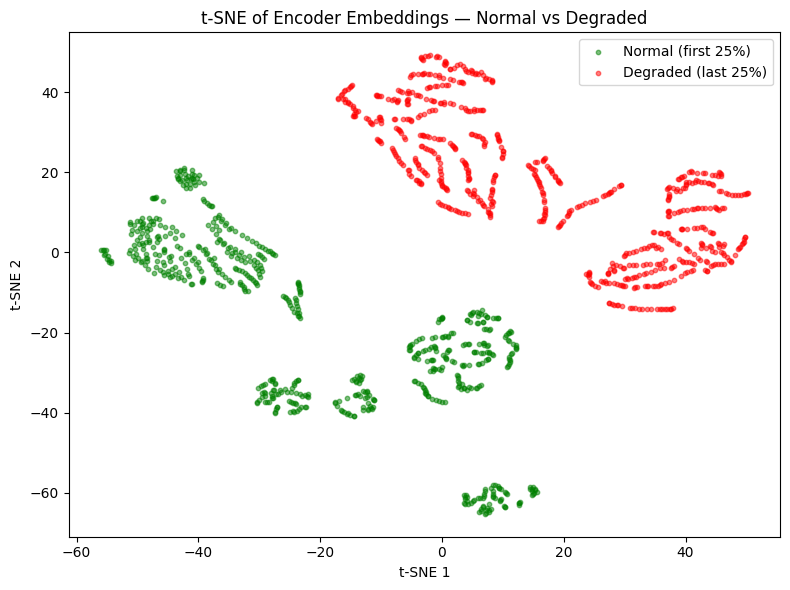

In [21]:
# t-SNE visualization of embeddings — normal vs degraded (Figure 5 recreation)
from sklearn.manifold import TSNE

normal_embs, degraded_embs = [], []
encoder.eval()
with torch.no_grad():
    for eid in train_eng_ids[:30]:  # sample 30 engines for speed
        eng    = train_data[train_data[0] == eid].reset_index(drop=True)
        total  = len(eng)
        cutoff_low  = int(0.25 * total)
        cutoff_high = int(0.75 * total)

        # first 25% = normal
        for w in get_windows(eng.iloc[:cutoff_low]):
            wp   = pca.transform(scaler.transform(w))
            wt   = torch.FloatTensor(wp).unsqueeze(0).to(device)
            m, d = compute_masking_and_delta(wt)
            emb  = encoder(torch.cat([wt, m, d], dim=2)).cpu().numpy()
            normal_embs.append(emb[0])

        # last 25% = degraded
        for w in get_windows(eng.iloc[cutoff_high:]):
            wp   = pca.transform(scaler.transform(w))
            wt   = torch.FloatTensor(wp).unsqueeze(0).to(device)
            m, d = compute_masking_and_delta(wt)
            emb  = encoder(torch.cat([wt, m, d], dim=2)).cpu().numpy()
            degraded_embs.append(emb[0])

normal_embs   = np.array(normal_embs)
degraded_embs = np.array(degraded_embs)
all_embs      = np.vstack([normal_embs, degraded_embs])
labels        = np.array([0]*len(normal_embs) + [1]*len(degraded_embs))

print(f'Normal windows: {len(normal_embs)} | Degraded windows: {len(degraded_embs)}')
print('Running t-SNE...')
tsne      = TSNE(n_components=2, random_state=42, perplexity=30)
embs_2d   = tsne.fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(embs_2d[labels==0, 0], embs_2d[labels==0, 1],
           c='green', s=10, alpha=0.5, label='Normal (first 25%)')
ax.scatter(embs_2d[labels==1, 0], embs_2d[labels==1, 1],
           c='red',   s=10, alpha=0.5, label='Degraded (last 25%)')
ax.set_title('t-SNE of Encoder Embeddings — Normal vs Degraded')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('fig_tsne.png', dpi=150)
plt.show()

## Build Reference HI Curves (80 Training Engines — as per paper)

In [22]:
# paper uses H = HI curves of all training instances (Section 4.2)
HI_curves_ref = {}
for eid in train_eng_ids:
    eng = train_data[train_data[0] == eid].reset_index(drop=True)
    HI_curves_ref[int(eid)] = get_hi_curve(eng, encoder, Z_norm, scale=HI_SCALE)

print(f'Reference HI curves: {len(HI_curves_ref)}')

Reference HI curves: 80


## HI Curve Visualization

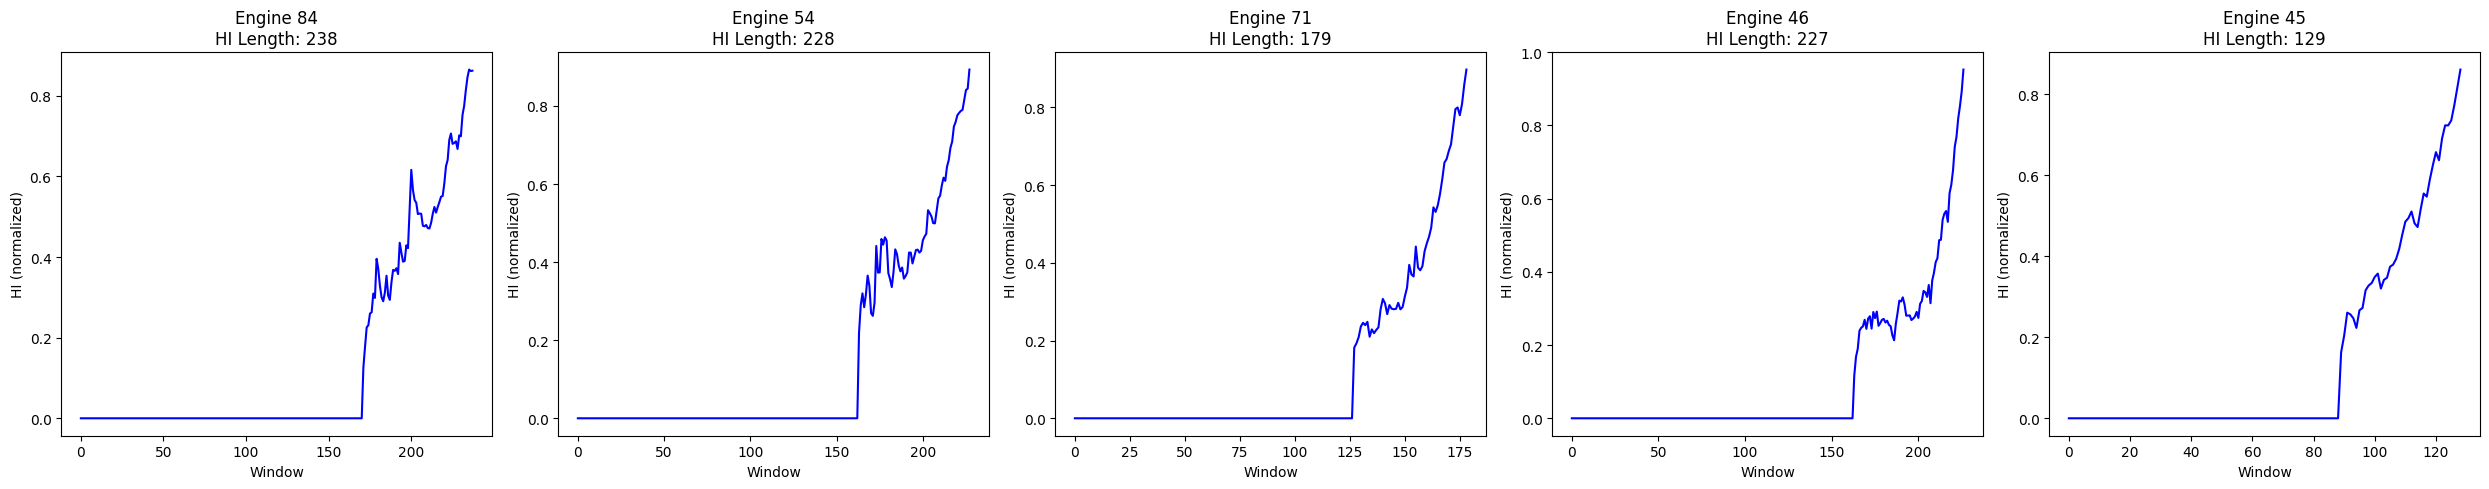

In [23]:
sample_ids = list(HI_curves_ref.keys())[:5]
fig, axes  = plt.subplots(1, 5, figsize=(25, 5))
for ax, eid in zip(axes, sample_ids):
    hi = HI_curves_ref[eid]
    ax.plot(hi, 'b-')
    ax.set_title(f'Engine {eid}\nHI Length: {len(hi)}')
    ax.set_xlabel('Window')
    ax.set_ylabel('HI (normalized)')
plt.tight_layout()
plt.savefig('fig_hi_curves.png', dpi=150)
plt.show()

## Evaluate Both Models on All Four Test Sets

In [24]:
results   = {}
all_preds = {}

gru_infer = gru_model.module if isinstance(gru_model, nn.DataParallel) else gru_model
gru_infer.eval()

for name, paths in PATHS.items():
    print(f'\nEvaluating {name}...')
    test_data = pd.read_csv(paths['test'], sep=r'\s+', header=None)
    rul_df    = pd.read_csv(paths['rul'],  sep=r'\s+', header=None)

    # GRU
    X_raw, eids = [], []
    for eid in test_data[0].unique():
        eng = test_data[test_data[0] == eid].reset_index(drop=True)
        if len(eng) >= GRU_SEQ_LEN:
            X_raw.append(eng.iloc[-GRU_SEQ_LEN:, 5:26].values)
            eids.append(int(eid))
    X_test = scaler.transform(np.array(X_raw).reshape(-1, 21)).reshape(len(X_raw), GRU_SEQ_LEN, 21)
    with torch.no_grad():
        gru_pred = gru_infer(torch.FloatTensor(X_test).to(device)).cpu().numpy().flatten()
    y_true = rul_df.iloc[np.array(eids) - 1, 0].values

    # Embed-RUL
    embed_pred = []
    for eid in eids:
        eng     = test_data[test_data[0] == eid].reset_index(drop=True)
        hi_test = get_hi_curve(eng, encoder, Z_norm, scale=HI_SCALE)
        embed_pred.append(estimate_rul(hi_test, HI_curves_ref))
    embed_pred = np.array(embed_pred)

    valid = int(np.sum(~np.isnan(embed_pred)))
    print(f'  GRU   RMSE: {np.sqrt(np.mean((gru_pred - y_true)**2)):.4f}')
    print(f'  Embed valid predictions: {valid}/{len(embed_pred)}')

    results[name] = {'gru': compute_metrics(y_true, gru_pred)}
    if valid > 0:
        results[name]['embed'] = compute_metrics(y_true, embed_pred)
        print(f'  Embed RMSE: {results[name]["embed"]["RMSE"]:.4f}  MAE: {results[name]["embed"]["MAE"]:.4f}')
    else:
        results[name]['embed'] = None
        print(f'  Embed: no valid predictions for {name}')

    all_preds[name] = {
        'y_true':     y_true,
        'gru_pred':   gru_pred,
        'embed_pred': embed_pred,
        'eids':       eids,
    }


Evaluating FD001...
  GRU   RMSE: 13.1693
  Embed valid predictions: 100/100
  Embed RMSE: 64.0153  MAE: 52.3283

Evaluating FD002...
  GRU   RMSE: 118.5355
  Embed valid predictions: 0/256
  Embed: no valid predictions for FD002

Evaluating FD003...
  GRU   RMSE: 42.0582
  Embed valid predictions: 65/100
  Embed RMSE: 70.2473  MAE: 58.7129

Evaluating FD004...
  GRU   RMSE: 124.5318
  Embed valid predictions: 0/241
  Embed: no valid predictions for FD004


## Full Results Table

In [25]:
metrics_order = ['RMSE', 'MAE', 'S', 'A_pct', 'FPR_pct', 'FNR_pct', 'MeanError', 'StdError']
labels        = ['RMSE', 'MAE', 'S', 'A(%)', 'FPR(%)', 'FNR(%)', 'Mean Error', 'Std Error']

print(f'{"Dataset":<8} {"Metric":<12} {"Baseline GRU":>15} {"Embed-RUL":>15}')
print('=' * 55)
for name in PATHS:
    em = results[name]['embed']
    for mk, ml in zip(metrics_order, labels):
        gv = results[name]['gru'][mk]
        ev = em[mk] if em is not None else float('nan')
        print(f'{name:<8} {ml:<12} {gv:>15.4f} {ev:>15.4f}')
    print('-' * 55)

print('\nPaired t-test on per-engine absolute error (valid predictions only):')
for name in PATHS:
    p        = all_preds[name]
    mask     = ~np.isnan(p['embed_pred'])
    if mask.sum() < 2:
        print(f'  {name}: insufficient valid Embed predictions to test')
        continue
    gru_ae   = np.abs(p['gru_pred'][mask]   - p['y_true'][mask])
    embed_ae = np.abs(p['embed_pred'][mask] - p['y_true'][mask])
    t, pval  = stats.ttest_rel(gru_ae, embed_ae)
    print(f'  {name}: t={t:.4f}, p={pval:.6f}, significant={pval < 0.05}')

Dataset  Metric          Baseline GRU       Embed-RUL
FD001    RMSE                 13.1693         64.0153
FD001    MAE                   9.7889         52.3283
FD001    S                   229.1382      84658.8328
FD001    A(%)                 60.0000         23.0000
FD001    FPR(%)               25.0000         73.0000
FD001    FNR(%)               15.0000          4.0000
FD001    Mean Error           -1.8557        -49.7474
FD001    Std Error            13.0380         40.2883
-------------------------------------------------------
FD002    RMSE                118.5355             nan
FD002    MAE                  99.8134             nan
FD002    S             329925045.3755             nan
FD002    A(%)                  6.6406             nan
FD002    FPR(%)               93.3594             nan
FD002    FNR(%)                0.0000             nan
FD002    Mean Error          -99.8000             nan
FD002    Std Error            63.9581             nan
--------------------------

## Figures — Actual vs Predicted and Error Histograms

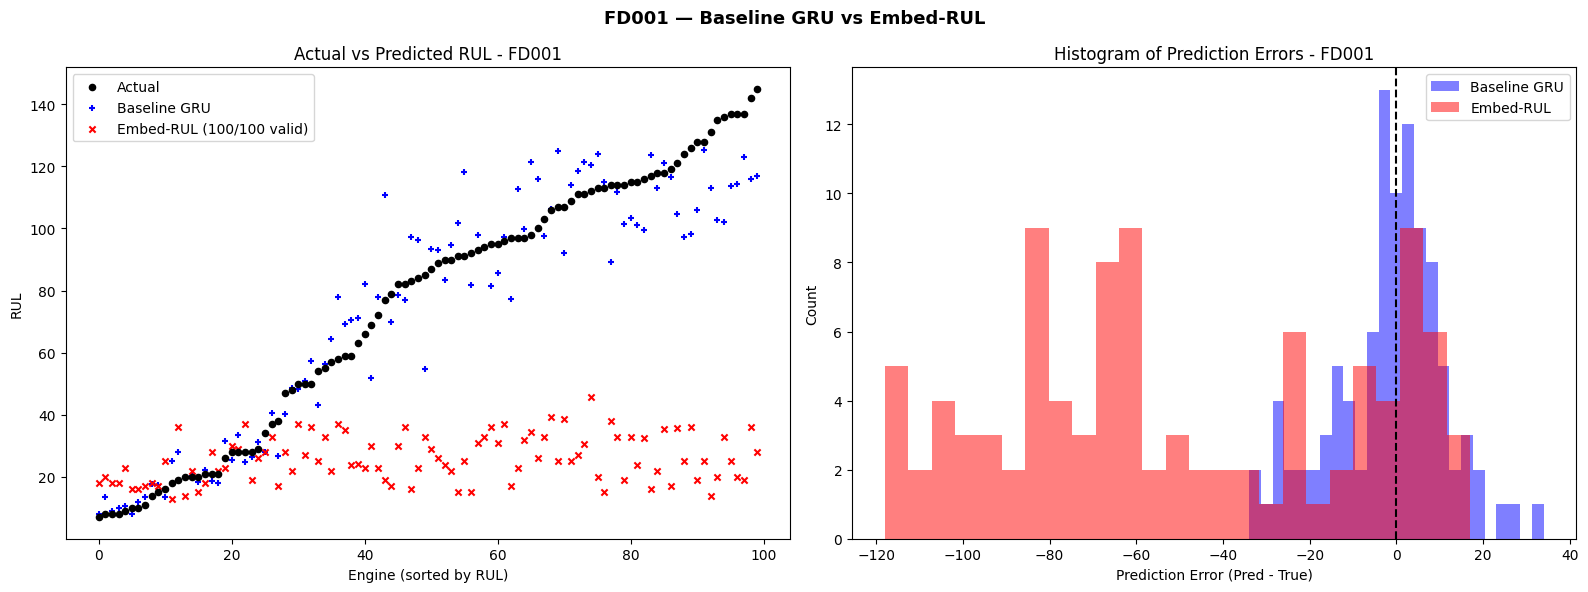

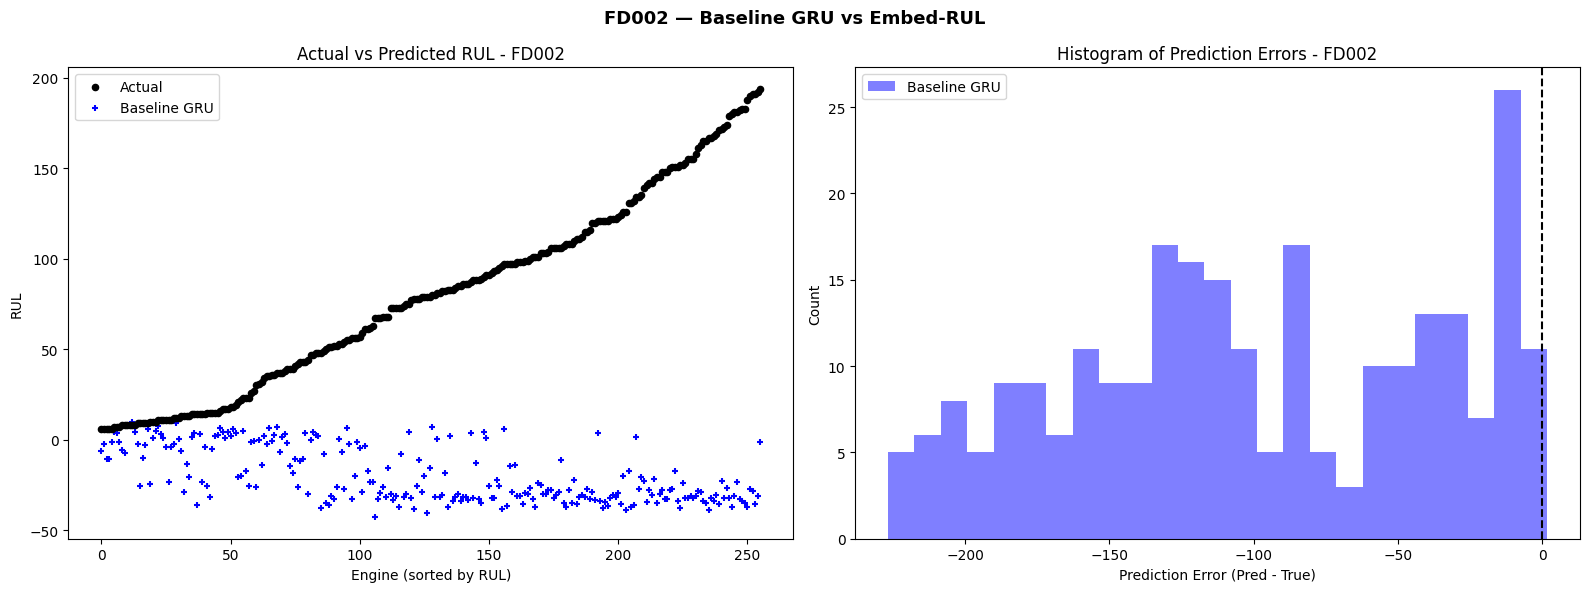

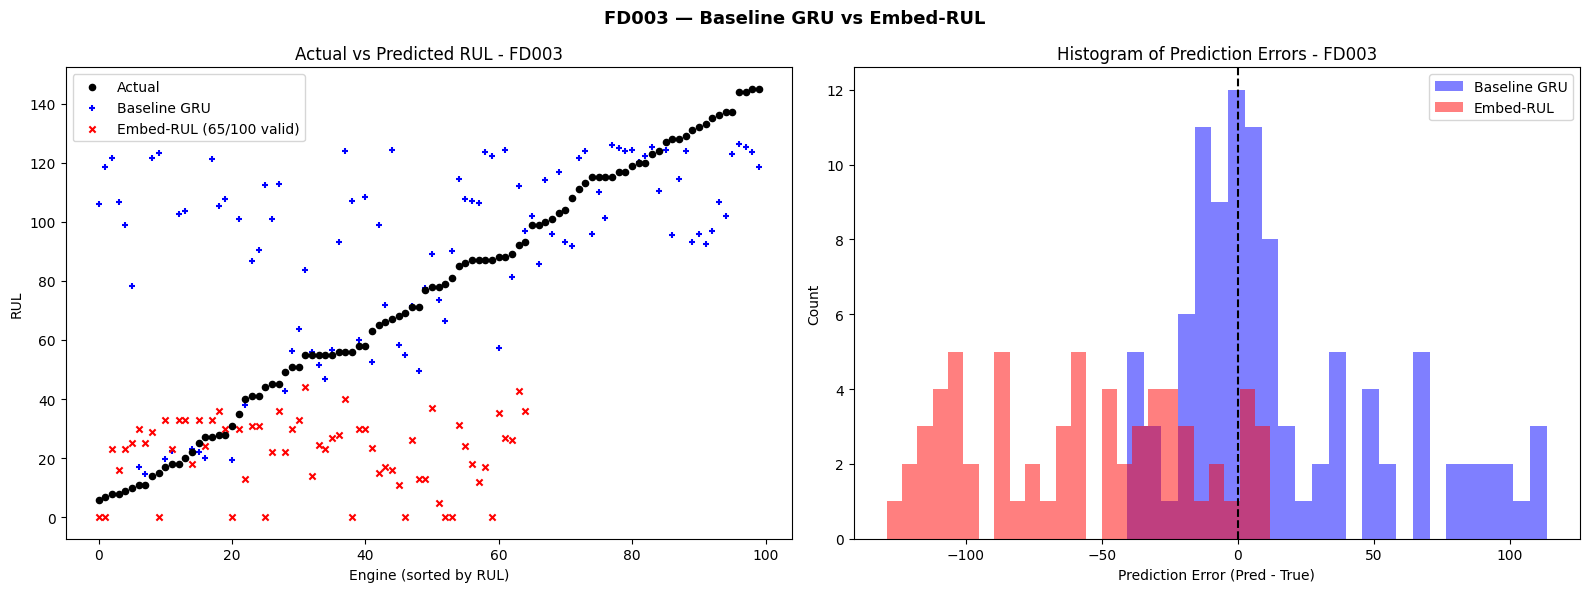

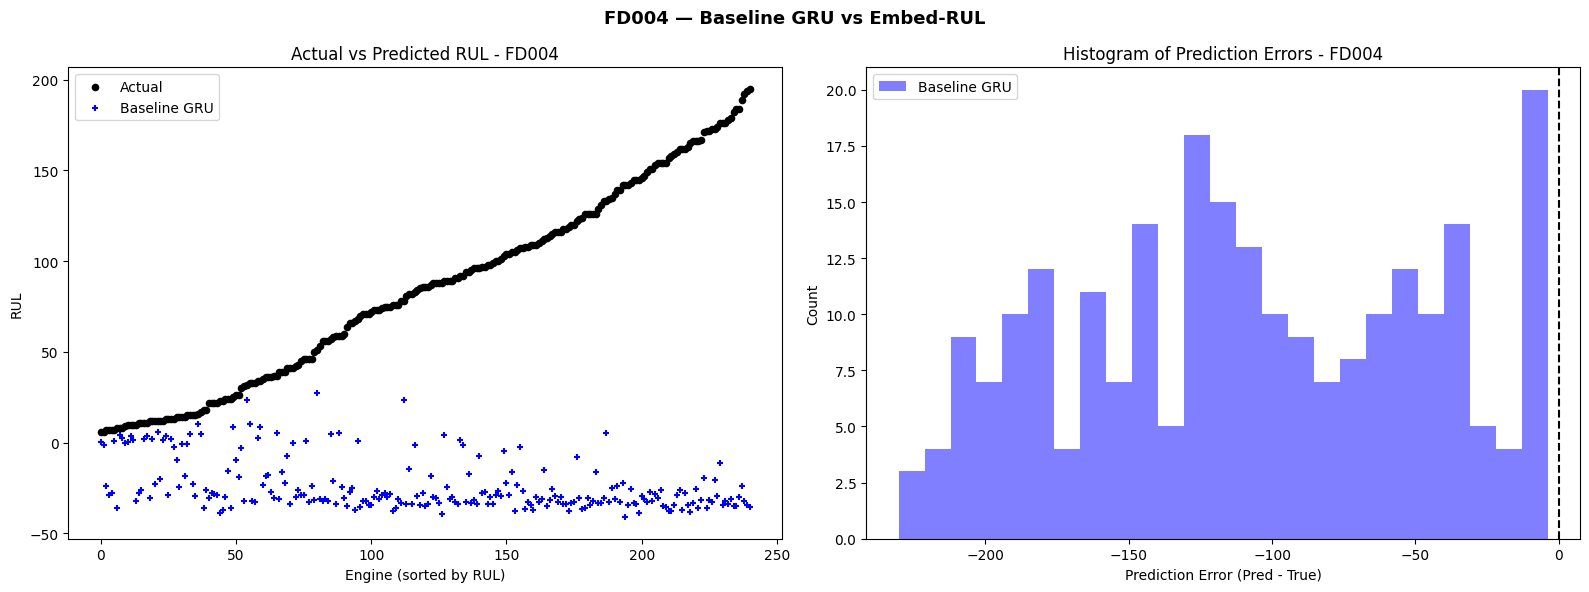

In [26]:
for name in PATHS:
    p        = all_preds[name]
    y_true   = p['y_true']
    gru_p    = p['gru_pred']
    embed_p  = p['embed_pred']
    sort_idx = np.argsort(y_true)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{name} — Baseline GRU vs Embed-RUL', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.scatter(range(len(y_true)), y_true[sort_idx],  c='black', s=20, label='Actual',       zorder=3)
    ax.scatter(range(len(y_true)), gru_p[sort_idx],   c='blue',  s=20, marker='+', label='Baseline GRU', zorder=2)
    valid_mask = ~np.isnan(embed_p)
    valid_sort = np.argsort(y_true[valid_mask])
    if valid_mask.sum() > 0:
        ax.scatter(range(valid_mask.sum()), embed_p[valid_mask][valid_sort],
                   c='red', s=20, marker='x', label=f'Embed-RUL ({valid_mask.sum()}/{len(y_true)} valid)', zorder=2)
    ax.set_xlabel('Engine (sorted by RUL)')
    ax.set_ylabel('RUL')
    ax.set_title(f'Actual vs Predicted RUL - {name}')
    ax.legend()

    ax = axes[1]
    gru_err = gru_p - y_true
    ax.hist(gru_err, bins=25, alpha=0.5, color='blue', label='Baseline GRU')
    if valid_mask.sum() > 0:
        embed_err = embed_p[valid_mask] - y_true[valid_mask]
        ax.hist(embed_err, bins=25, alpha=0.5, color='red', label='Embed-RUL')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_xlabel('Prediction Error (Pred - True)')
    ax.set_ylabel('Count')
    ax.set_title(f'Histogram of Prediction Errors - {name}')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'fig_{name}.png', dpi=150)
    plt.show()